# ECG Sliding Window Classification
Notebook này tập trung vào pipeline phân loại ECG theo cửa sổ trượt, bám theo cách trình bày của các notebook `01_explore_data`, `02_EDA`, và `03_preprocessing_data`.

## Nội dung
1. Setup & Libraries
2. Data Split theo record cố định
3. Load ECG từ MIT-BIH
4. Preprocessing + Feature Engineering
5. Build Sliding Window Dataset
6. Training & Evaluation (RF, ET, XGB, Soft Voting)
7. So sánh cấu hình 4.5s vs 9s
8. EDA & Visualization kết quả
9. Confusion Matrix & nhận xét cuối

## Ghi chú chạy
- Chạy tuần tự từ trên xuống dưới.
- Cell thực nghiệm 4.5s/9s là cell tốn thời gian nhất.
- Các cell cuối dùng để tổng hợp bảng và hình cho báo cáo.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb

from tqdm import tqdm
from collections import Counter

from scipy.signal import butter, filtfilt, iirnotch
from scipy.stats import skew, kurtosis

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
np.random.seed(42)

## 1. Data Split by Records
Phần này thiết lập tập `train/validation/test` theo danh sách record cố định của báo cáo để đảm bảo tái lập kết quả và không có overlap giữa các tập.

In [2]:
TRAIN_RECORDS = [
    "100", "101", "107", "108", "109", "111", "112", "113", "114", "115",
    "116", "117", "118", "119", "121", "122", "123", "124", "201", "202",
    "203", "205", "207", "209", "210", "212", "213", "214", "215", "217",
    "219", "220", "221", "222", "223", "228", "230", "231",
]

VAL_RECORDS = ["200", "208", "232", "233", "234"]
TEST_RECORDS = ["102", "103", "104", "105", "106"]

all_records = sorted(set(TRAIN_RECORDS + VAL_RECORDS + TEST_RECORDS))

print("=" * 80)
print("FIXED RECORD SPLIT (THEO BAO CAO)")
print("=" * 80)
print(f"Train records ({len(TRAIN_RECORDS)}): {TRAIN_RECORDS}")
print(f"Validation records ({len(VAL_RECORDS)}): {VAL_RECORDS}")
print(f"Test records ({len(TEST_RECORDS)}): {TEST_RECORDS}")

overlap = (set(TRAIN_RECORDS) & set(VAL_RECORDS)) | (set(TRAIN_RECORDS) & set(TEST_RECORDS)) | (set(VAL_RECORDS) & set(TEST_RECORDS))
print(f"Overlap check: {overlap if overlap else 'No overlap'}")
print("=" * 80)

FIXED RECORD SPLIT (THEO BAO CAO)
Train records (38): ['100', '101', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '201', '202', '203', '205', '207', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231']
Validation records (5): ['200', '208', '232', '233', '234']
Test records (5): ['102', '103', '104', '105', '106']
Overlap check: No overlap


## 2. Load ECG Data (MIT-BIH)
Phần này định nghĩa hàm đọc tín hiệu ECG và annotation từ MIT-BIH: ưu tiên dữ liệu local trong thư mục dự án, nếu thiếu sẽ fallback sang PhysioNet.

In [3]:
PROJECT_DIR = Path.cwd()
LOCAL_MITDB_DIR = PROJECT_DIR / "notebooks" / "mitdb"

def load_mitbih_record(record_id, local_dir=LOCAL_MITDB_DIR):
    """Load MIT-BIH record from local folder first, then fall back to PhysioNet."""
    rec_path = local_dir / record_id

    if (local_dir / f"{record_id}.hea").exists():
        record = wfdb.rdrecord(str(rec_path))
        ann = wfdb.rdann(str(rec_path), "atr")
    else:
        record = wfdb.rdrecord(record_id, pn_dir="mitdb")
        ann = wfdb.rdann(record_id, "atr", pn_dir="mitdb")

    signal_1d = record.p_signal[:, 0].astype(np.float64)
    fs = float(record.fs)
    ann_samples = np.asarray(ann.sample, dtype=int)
    ann_symbols = np.asarray(ann.symbol)
    return signal_1d, fs, ann_samples, ann_symbols

## 3. Preprocessing & Feature Engineering
Các cell tiếp theo gồm 3 nhóm chính:
- Tiền xử lý tín hiệu ECG (band-pass, notch, detrend, chuẩn hóa cửa sổ).
- Trích xuất feature frame-level và window-level.
- Quy tắc gán nhãn cho từng cửa sổ trượt dựa trên beat gần tâm cửa sổ.

In [4]:
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    return b, a

def apply_bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return filtfilt(b, a, signal)

def apply_notch_filter(signal, fs, notch_freq=60.0, quality=30):
    b, a = iirnotch(notch_freq, quality, fs)
    return filtfilt(b, a, signal)

def remove_baseline(signal):
    from scipy.signal import detrend
    return detrend(signal, type="linear")

def preprocess_ecg(signal, fs):
    x = apply_bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=4)
    x = apply_notch_filter(x, fs, notch_freq=60.0, quality=30)
    x = remove_baseline(x)
    return x

def z_normalize_1d(x):
    x = np.asarray(x, dtype=np.float64)
    mu = np.mean(x)
    sigma = np.std(x)
    if sigma < 1e-8:
        return x - mu
    return (x - mu) / sigma

In [5]:
VALID_SYMBOLS = {"N", "V", "A", "L", "R"}

def safe_skew(x):
    if np.std(x) < 1e-8:
        return 0.0
    return float(skew(x))

def safe_kurtosis(x):
    if np.std(x) < 1e-8:
        return 0.0
    return float(kurtosis(x))

def compute_frame_features(frame):
    frame = np.asarray(frame, dtype=np.float64)
    diff1 = np.diff(frame)
    diff2 = np.diff(frame, n=2)
    q25, q75 = np.percentile(frame, [25, 75])

    return {
        "mean": float(np.mean(frame)),
        "std": float(np.std(frame)),
        "min": float(np.min(frame)),
        "max": float(np.max(frame)),
        "iqr": float(q75 - q25),
        "rms": float(np.sqrt(np.mean(frame ** 2))),
        "absolute_sum_of_changes": float(np.sum(np.abs(diff1))) if len(diff1) else 0.0,
        "mean_abs_change": float(np.mean(np.abs(diff1))) if len(diff1) else 0.0,
        "line_length": float(np.sum(np.abs(diff1))) if len(diff1) else 0.0,
        "second_derivative": float(np.mean(np.abs(diff2))) if len(diff2) else 0.0,
        "skewness": safe_skew(frame),
        "kurtosis": safe_kurtosis(frame),
        "peak_to_peak_amplitude": float(np.ptp(frame)),
    }

def compute_window_level_features(r_peaks, fs, include_rmssd=False):
    beat_count = int(len(r_peaks))

    if beat_count >= 2:
        rr = np.diff(r_peaks) / fs
        mean_rr = float(np.mean(rr))
        median_rr = float(np.median(rr))
        rr_range = float(np.max(rr) - np.min(rr))

        rr_mean = np.mean(rr)
        rr_std = np.std(rr) + 1e-8
        rr_norm = (rr - rr_mean) / rr_std
        normalized_rr_mean = float(np.mean(rr_norm))
        normalized_rr_std = float(np.std(rr_norm))

        hr = 60.0 / (rr + 1e-8)
        mean_hr = float(np.mean(hr))
        hr_range = float(np.max(hr) - np.min(hr))

        rmssd = float(np.sqrt(np.mean(np.diff(rr) ** 2))) if len(rr) >= 2 else 0.0
    else:
        mean_rr = median_rr = rr_range = 0.0
        normalized_rr_mean = normalized_rr_std = 0.0
        mean_hr = hr_range = 0.0
        rmssd = 0.0

    features = {
        "beat_count": beat_count,
        "mean_RR": mean_rr,
        "median_RR": median_rr,
        "RR_range": rr_range,
        "normalized_RR_mean": normalized_rr_mean,
        "normalized_RR_std": normalized_rr_std,
        "mean_HR": mean_hr,
        "HR_range": hr_range,
    }

    if include_rmssd:
        features["RMSSD"] = rmssd

    return features

In [6]:
def extract_window_features(
    signal,
    ann_samples,
    ann_symbols,
    start,
    end,
    fs,
    frame_seconds=0.75,
    include_rmssd=False,
):
    window = signal[start:end]
    window = z_normalize_1d(window)

    in_window = (ann_samples >= start) & (ann_samples < end)
    local_samples = ann_samples[in_window]
    local_symbols = ann_symbols[in_window]

    valid_mask = np.array([s in VALID_SYMBOLS for s in local_symbols], dtype=bool)
    valid_samples = local_samples[valid_mask]
    valid_symbols = local_symbols[valid_mask]

    if len(valid_samples) == 0:
        return None, None

    center = start + (end - start) // 2
    nearest_idx = int(np.argmin(np.abs(valid_samples - center)))
    center_symbol = str(valid_symbols[nearest_idx])
    label = 0 if center_symbol == "N" else 1

    feature_dict = {}
    window_level = compute_window_level_features(valid_samples, fs, include_rmssd=include_rmssd)
    feature_dict.update(window_level)

    frame_len = int(frame_seconds * fs)
    n_frames = (end - start) // frame_len

    for i in range(n_frames):
        f_start = i * frame_len
        f_end = f_start + frame_len
        frame = window[f_start:f_end]
        if len(frame) < frame_len:
            continue

        f_feats = compute_frame_features(frame)
        for k, v in f_feats.items():
            feature_dict[f"f{i+1}_{k}"] = v

    meta = {
        "start": int(start),
        "end": int(end),
        "center_symbol": center_symbol,
        "beat_count": int(window_level["beat_count"]),
    }
    return feature_dict, label, meta

## 4. Build Sliding Window Dataset
Cell tiếp theo tạo dataset đặc trưng cho từng tập record và in thống kê số lượng mẫu theo lớp (`Normal/Abnormal`) sau khi dựng cửa sổ trượt.

In [7]:
def build_dataset(record_ids, window_seconds, step_ratio=0.5, frame_seconds=0.75):
    rows = []
    labels = []
    metadata = []

    for rid in tqdm(record_ids, desc=f"Build {window_seconds}s windows"):
        try:
            signal, fs, ann_samples, ann_symbols = load_mitbih_record(rid)
            signal = preprocess_ecg(signal, fs)
        except Exception as exc:
            print(f"[WARN] Skip record {rid}: {exc}")
            continue

        win_len = int(window_seconds * fs)
        step = int(win_len * step_ratio)
        include_rmssd = window_seconds >= 10.0

        for start in range(0, len(signal) - win_len + 1, step):
            end = start + win_len
            out = extract_window_features(
                signal=signal,
                ann_samples=ann_samples,
                ann_symbols=ann_symbols,
                start=start,
                end=end,
                fs=fs,
                frame_seconds=frame_seconds,
                include_rmssd=include_rmssd,
            )

            if out[0] is None:
                continue

            feats, label, meta = out
            meta["record_id"] = rid
            rows.append(feats)
            labels.append(label)
            metadata.append(meta)

    X = pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    y = np.asarray(labels, dtype=int)
    meta_df = pd.DataFrame(metadata)
    return X, y, meta_df

def summarize_split(name, X, y):
    c = Counter(y.tolist()) if len(y) else Counter()
    print(f"{name}: {len(y):,} windows, {X.shape[1]} features")
    print(f"  Normal (0): {c.get(0, 0):,}")
    print(f"  Abnormal (1): {c.get(1, 0):,}")

## 5. Training & Evaluation Pipeline
Cell này định nghĩa hàm `run_experiment` cho toàn bộ pipeline huấn luyện:
- Chuẩn hóa bằng `StandardScaler`.
- Cân bằng lớp train bằng `SMOTE`.
- Chọn đặc trưng bằng `SelectKBest (k=25)`.
- Huấn luyện `RandomForest`, `ExtraTrees`, `XGBoost`.
- Soft voting có trọng số `0.3 / 0.3 / 0.4` và ngưỡng phân loại `0.5`.

In [8]:
def evaluate_predictions(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

def run_experiment(window_seconds, threshold=0.5, k_best=25):
    print("\n" + "=" * 90)
    print(f"RUN EXPERIMENT - WINDOW {window_seconds}s")
    print("=" * 90)

    X_train, y_train, meta_train = build_dataset(TRAIN_RECORDS, window_seconds=window_seconds)
    X_val, y_val, meta_val = build_dataset(VAL_RECORDS, window_seconds=window_seconds)
    X_test, y_test, meta_test = build_dataset(TEST_RECORDS, window_seconds=window_seconds)

    print("\nDataset sizes after sliding window")
    summarize_split("Train", X_train, y_train)
    summarize_split("Validation", X_val, y_val)
    summarize_split("Test", X_test, y_test)

    common_cols = sorted(set(X_train.columns) | set(X_val.columns) | set(X_test.columns))
    X_train = X_train.reindex(columns=common_cols, fill_value=0.0)
    X_val = X_val.reindex(columns=common_cols, fill_value=0.0)
    X_test = X_test.reindex(columns=common_cols, fill_value=0.0)

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc = scaler.transform(X_val)
    X_test_sc = scaler.transform(X_test)

    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)
    print("\nAfter SMOTE (train only):", Counter(y_train_bal))

    selector = SelectKBest(score_func=f_classif, k=min(k_best, X_train_bal.shape[1]))
    X_train_sel = selector.fit_transform(X_train_bal, y_train_bal)
    X_val_sel = selector.transform(X_val_sc)
    X_test_sel = selector.transform(X_test_sc)

    selected_feature_names = np.array(common_cols)[selector.get_support()]
    print(f"Selected features: {len(selected_feature_names)} / {len(common_cols)}")

    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced_subsample",
            n_jobs=-1,
        ),
        "ExtraTrees": ExtraTreesClassifier(
            n_estimators=400,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1,
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss",
            verbosity=0,
        ),
    }

    model_metrics = {}
    model_pred = {}
    model_proba = {}

    for model_name, model in models.items():
        model.fit(X_train_sel, y_train_bal)
        proba_test = model.predict_proba(X_test_sel)[:, 1]
        pred_test = (proba_test >= threshold).astype(int)

        model_proba[model_name] = proba_test
        model_pred[model_name] = pred_test
        model_metrics[model_name] = evaluate_predictions(y_test, pred_test)

    weights = {"RandomForest": 0.3, "ExtraTrees": 0.3, "XGBoost": 0.4}
    ensemble_proba = sum(weights[m] * model_proba[m] for m in weights)
    ensemble_pred = (ensemble_proba >= threshold).astype(int)
    ensemble_metrics = evaluate_predictions(y_test, ensemble_pred)

    rows = []
    for m in ["RandomForest", "ExtraTrees", "XGBoost"]:
        rows.append({"Config": f"{window_seconds}s", "Model": m, **model_metrics[m]})
    rows.append({"Config": f"{window_seconds}s", "Model": "SoftVoting(0.3/0.3/0.4)", **ensemble_metrics})
    report_df = pd.DataFrame(rows).sort_values(["F1", "Recall", "Accuracy"], ascending=False).reset_index(drop=True)

    print("\nModel results on test")
    print(report_df.to_string(index=False))

    return {
        "window_seconds": window_seconds,
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test,
        "meta_train": meta_train,
        "meta_val": meta_val,
        "meta_test": meta_test,
        "report": report_df,
        "model_pred": model_pred,
        "ensemble_pred": ensemble_pred,
        "ensemble_metrics": ensemble_metrics,
        "selected_features": selected_feature_names.tolist(),
    }

## 6. Run Experiments (4.5s vs 9s)
Cell tiếp theo chạy thực nghiệm cho 2 cấu hình cửa sổ (`4.5s` và `9s`) và tạo bảng tổng hợp metric trên tập test.

In [ ]:
results_45 = run_experiment(window_seconds=4.5, threshold=0.5, k_best=25)
results_90 = run_experiment(window_seconds=9.0, threshold=0.5, k_best=25)

summary_results = pd.concat([results_45["report"], results_90["report"]], ignore_index=True)
summary_results = summary_results.sort_values(["F1", "Recall", "Accuracy"], ascending=False).reset_index(drop=True)

print("\n" + "=" * 90)
print("TỔNG HỢP KẾT QUẢ 4.5s vs 9s")
print("=" * 90)
print(summary_results.to_string(index=False))

✓ Advanced preprocessing function defined


## 7. EDA on Extracted Features
Phần này trực quan hóa đặc trưng sau khi build dữ liệu:
- Boxplot 4 feature tiêu biểu giữa hai lớp.
- Heatmap tương quan của nhóm window-level features.
- Thống kê số lượng feature giữa hai cấu hình cửa sổ.


FEATURE COUNTS
Config  Frame-level  Window-level  Total
  4.5s           78             8     86
    9s          156             8    164


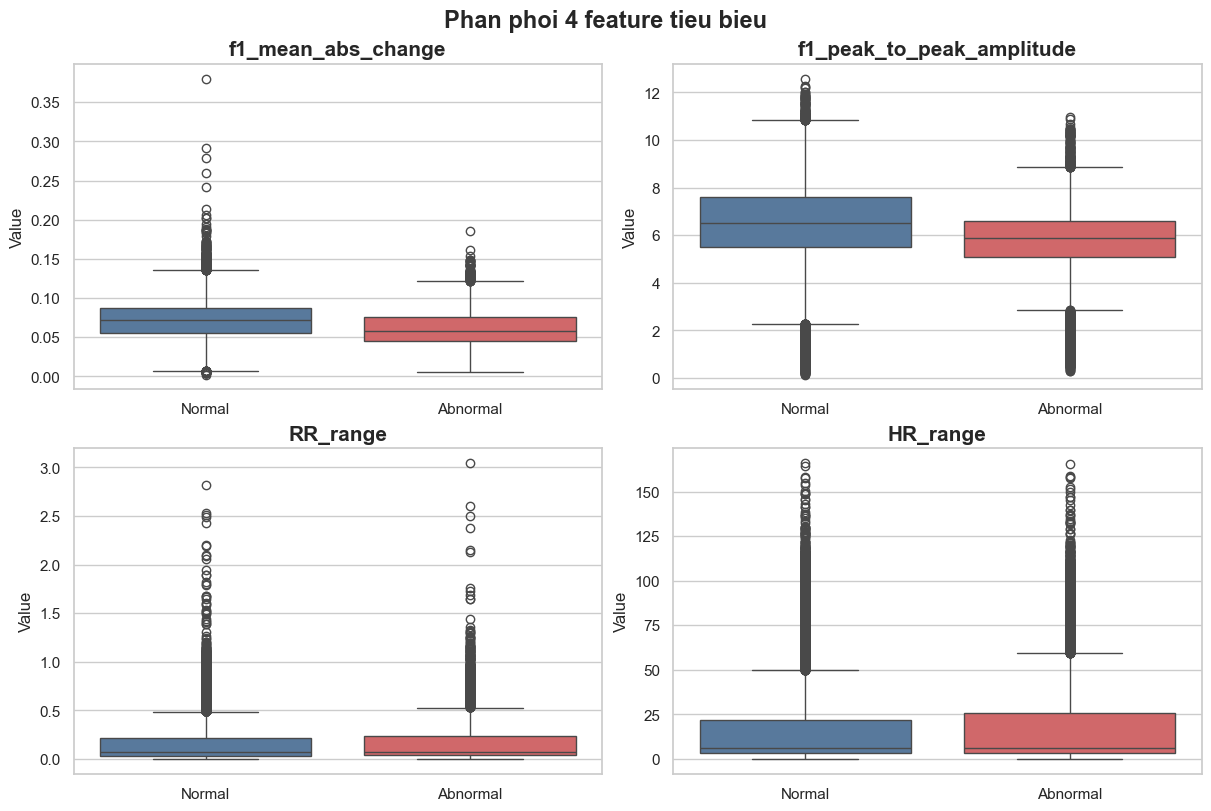

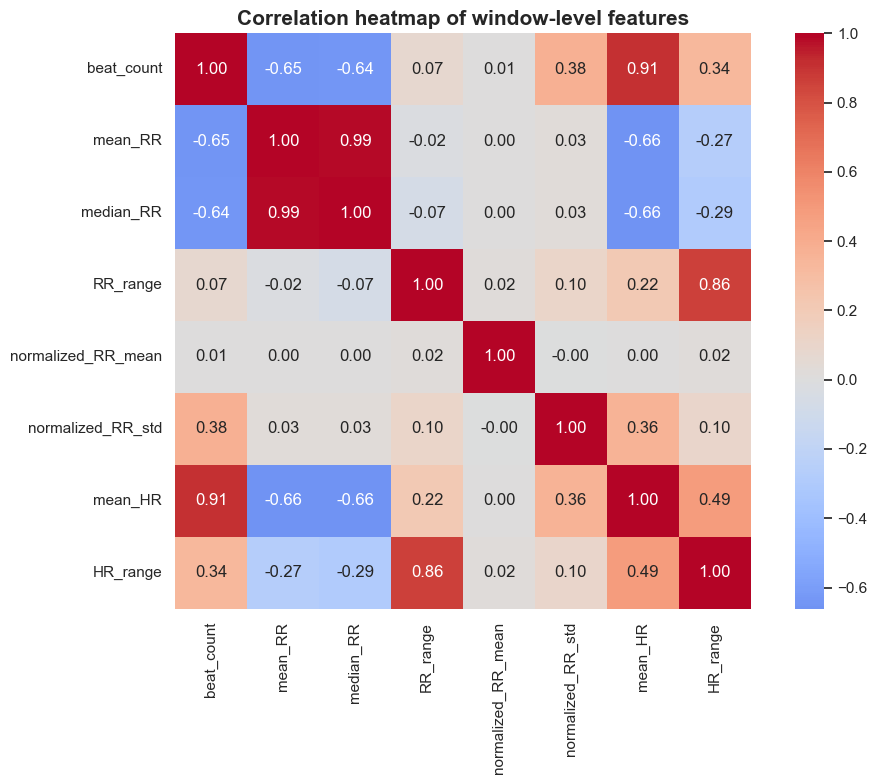

In [ ]:
def feature_group_summary(columns):
    frame_cols = [c for c in columns if c.startswith("f") and "_" in c]
    window_cols = [c for c in columns if c not in frame_cols]
    return {
        "frame_level": len(frame_cols),
        "window_level": len(window_cols),
        "total": len(columns),
    }

f45 = feature_group_summary(results_45["X_train"].columns.tolist())
f90 = feature_group_summary(results_90["X_train"].columns.tolist())

feature_count_df = pd.DataFrame([
    {"Config": "4.5s", "Frame-level": f45["frame_level"], "Window-level": f45["window_level"], "Total": f45["total"]},
    {"Config": "9s", "Frame-level": f90["frame_level"], "Window-level": f90["window_level"], "Total": f90["total"]},
])

print("\nTHỐNG KÊ SỐ LƯỢNG FEATURE")
print(feature_count_df.to_string(index=False))

# Hình 1: Phân phối 4 feature tiêu biểu
feature_for_box = ["f1_mean_abs_change", "f1_peak_to_peak_amplitude", "RR_range", "HR_range"]
feature_for_box = [c for c in feature_for_box if c in results_45["X_train"].columns]

if len(feature_for_box) > 0:
    df_plot = results_45["X_train"][feature_for_box].copy()
    df_plot["label_name"] = np.where(results_45["y_train"] == 0, "Normal", "Abnormal")

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    axes = axes.ravel()
    for i, col in enumerate(feature_for_box):
        sns.boxplot(data=df_plot, x="label_name", y=col, ax=axes[i], palette=["#4C78A8", "#E15759"])
        axes[i].set_title(col, fontsize=15, fontweight="bold")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Giá trị")
    fig.suptitle("Phân phối 4 feature tiêu biểu", fontsize=17, fontweight="bold")
    plt.show()

# Hình 2: Correlation heatmap của feature window-level
window_feats = [
    c for c in [
        "beat_count", "mean_RR", "median_RR", "RR_range",
        "normalized_RR_mean", "normalized_RR_std", "mean_HR", "HR_range",
    ]
    if c in results_45["X_train"].columns
]

if len(window_feats) > 1:
    corr_df = results_45["X_train"][window_feats].corr()
    plt.figure(figsize=(10.5, 8))
    sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
    plt.title("Correlation heatmap của feature window-level", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 8. Model Comparison Table
Cell tiếp theo in bảng so sánh metric giữa `RandomForest`, `ExtraTrees`, `XGBoost` cho hai cấu hình cửa sổ 4.5s và 9s.

In [17]:
def metrics_row(report_df, model_name):
    row = report_df.loc[report_df["Model"] == model_name]
    if row.empty:
        return None
    row = row.iloc[0]
    return {
        "Accuracy": float(row["Accuracy"]),
        "Precision": float(row["Precision"]),
        "Recall": float(row["Recall"]),
        "F1-score": float(row["F1"]),
    }

model_order = ["RandomForest", "ExtraTrees", "XGBoost"]
metrics_order = ["Accuracy", "Precision", "Recall", "F1-score"]

table_rows = []
for m in model_order:
    r45 = metrics_row(results_45["report"], m)
    r90 = metrics_row(results_90["report"], m)
    if r45 is None or r90 is None:
        continue

    row = {"Model": m}
    for met in metrics_order:
        row[f"4.5s_{met}"] = r45[met]
        row[f"9s_{met}"] = r90[met]
    table_rows.append(row)

metric_table = pd.DataFrame(table_rows)
print("\nBảng so sánh metric 3 model (4.5s vs 9s)")
print(metric_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


Bảng so sánh metric 3 model (4.5s vs 9s)
       Model  4.5s_Accuracy  9s_Accuracy  4.5s_Precision  9s_Precision  4.5s_Recall  9s_Recall  4.5s_F1-score  9s_F1-score
RandomForest         0.7735       0.7281          0.2012        0.1552       0.6634     0.5495         0.3088       0.2421
  ExtraTrees         0.7712       0.7018          0.1863        0.0882       0.5941     0.2973         0.2837       0.1361
     XGBoost         0.7339       0.6790          0.1922        0.1559       0.7772     0.6937         0.3081       0.2545


## 9. Confusion Matrix & Final Notes
Cell cuối cùng vẽ confusion matrix cho hai cấu hình nổi bật và in thống kê `False Negative` để hỗ trợ nhận xét cuối cho bài toán phát hiện bất thường ECG.

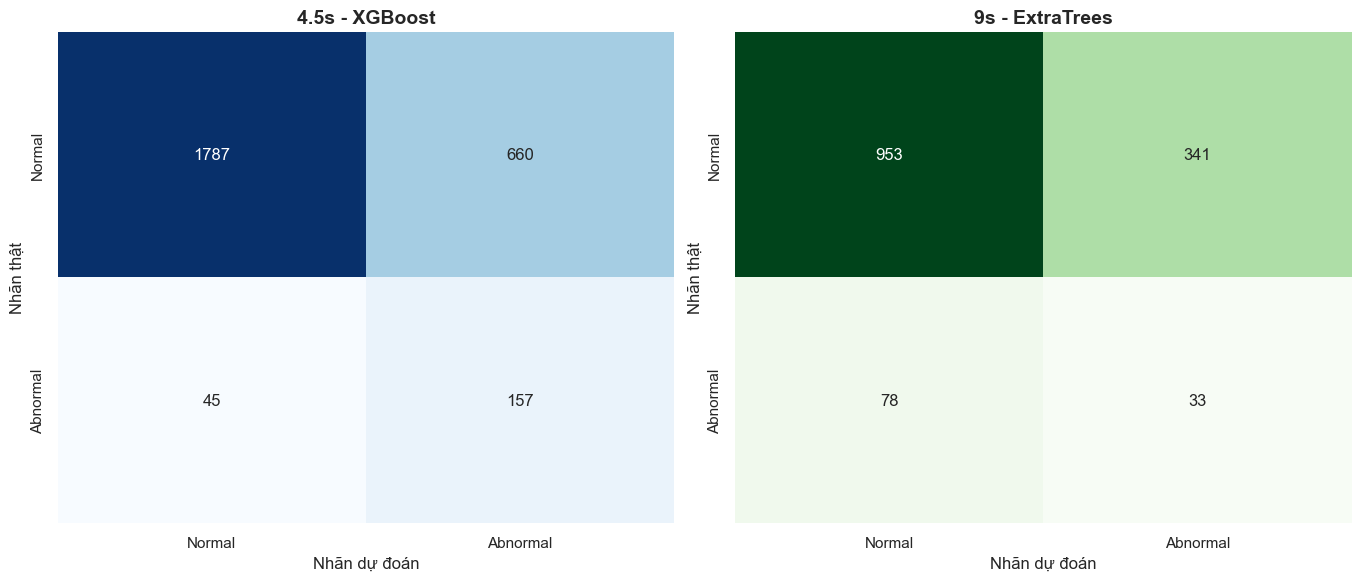

In [16]:
def get_prediction_by_name(result_obj, model_name):
    if model_name == "SoftVoting(0.3/0.3/0.4)":
        return result_obj["ensemble_pred"]
    return result_obj["model_pred"][model_name]

# Hình 4: Confusion matrix cho 2 mô hình nổi bật
model_45_plot = "XGBoost" if "XGBoost" in results_45["report"]["Model"].values else results_45["report"].iloc[0]["Model"]
model_90_plot = "ExtraTrees" if "ExtraTrees" in results_90["report"]["Model"].values else results_90["report"].iloc[0]["Model"]

pred_45 = get_prediction_by_name(results_45, model_45_plot)
pred_90 = get_prediction_by_name(results_90, model_90_plot)

cm_45 = confusion_matrix(results_45["y_test"], pred_45)
cm_90 = confusion_matrix(results_90["y_test"], pred_90)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.7), constrained_layout=True)

sns.heatmap(
    cm_45,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"],
    ax=axes[0],
)
axes[0].set_title(f"4.5s - {model_45_plot}", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Nhãn dự đoán")
axes[0].set_ylabel("Nhãn thật")

sns.heatmap(
    cm_90,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"],
    ax=axes[1],
)
axes[1].set_title(f"9s - {model_90_plot}", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Nhãn dự đoán")
axes[1].set_ylabel("Nhãn thật")

plt.show()

fn_45 = int(cm_45[1, 0])
fn_90 = int(cm_90[1, 0])
